In [16]:
from bam_utils import *

import torch
import torch.nn as nn
from torch.nn import functional as F
import itertools

from dataclasses import dataclass
from collections import defaultdict
from typing import Dict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}.")

Using cuda.


### Loading Data

In [64]:
from torch.utils.data import DataLoader
from dataset_old import LargeIterableDataset

batch_size=256
nw = 20

test_list = '/home/zouy1/projects/RNAmod/VAE/input/DNA/input_oligos_7mer_new/'+'/test/'
test_list = list(Path(test_list).rglob("*.pt"))
mod_list ='/home/zouy1/projects/RNAmod/VAE/input/DNA/input_oligos_7mer_5hmC_umair/'+'/mod/'
mod_list =list(Path(mod_list).rglob("*0.pt"))

test_dataset = LargeIterableDataset(test_list, max_samples=200000, compute_len=True)
mod_dataset = LargeIterableDataset(mod_list, max_samples=200000, compute_len=True)

test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=True, prefetch_factor=4)
mod_loader  = DataLoader(mod_dataset,  batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=True, prefetch_factor=4)

### Evaluation

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt

In [19]:
# Import model
import importlib
import models.model_v1_cnn_t as m  # change model here
importlib.reload(m)
model_name = m.META.name

model = m.VAE(
    n_features=11,
    seq_len=7,
    d_model=64,
    cnn_channels=64,
    n_heads=4,
    n_layers=3,
    latent_dim=16,
    dropout=0.1,
    use_cls_token=True,
).to(device)

run_name = "online_test3"
n_epoch = "3"
#pt = torch.load(f"state_dicts/{model_name}/{run_name}-epoch{n_epoch}.pt", map_location=device)
pt = torch.load("state_dicts/model_v1_cnn_t/model_vae_cnn_be-3_e50.pt", map_location=device)
#pt = torch.load("state_dicts/model_v1_cnn_t/static_test1.pt", map_location=device)

model.load_state_dict(pt['model_state_dict'])
last_beta = pt['beta']

#check params
num_nonzero = sum((p.abs() > 1e-6).sum().item() for p in model.parameters())
nparam = sum([p.numel() for p in model.parameters()])
print(f"non-zero params: {100*num_nonzero/nparam}%")

non-zero params: 99.99756331041685%


/home/zouy1/miniconda3/envs/deepmod2/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [65]:
# Anomaly scoring: per-sample reconstruction error
def anomaly_score(model, loader, beta, device):
    model.eval()
    scores = []
    with torch.no_grad():
        for x, _, _ in loader:
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))  # [B]
            #kl_score = 0.5 * torch.sum(out["mu"]**2 + out["logvar"].exp() - out["logvar"] - 1, dim=1)
            #elbo_score = recon_score + beta * kl_score
            scores.append(recon_score.detach().cpu())
        print("mu std:", out["mu"].std(dim=0).mean().item())
        print("logvar mean:", out["logvar"].mean().item())
    return torch.cat(scores, dim=0)
scores_test = anomaly_score(model, test_loader, last_beta, device)
scores_mod = anomaly_score(model, mod_loader, last_beta, device)
print(f"unmod score (mean): {scores_test.mean().item()}, mod score (mean): {scores_mod.mean().item()}")

mu std: 0.564115047454834
logvar mean: -2.2628815174102783
mu std: 0.5979156494140625
logvar mean: -2.173879384994507
unmod score (mean): 0.010728072375059128, mod score (mean): 0.021814480423927307


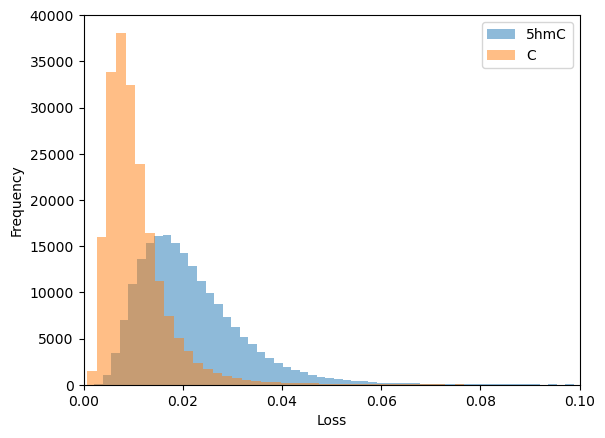

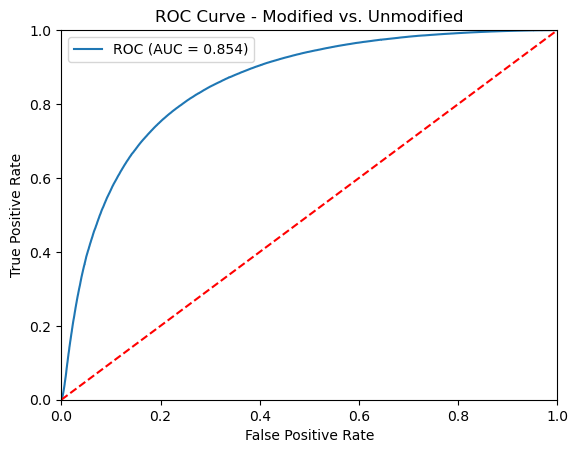

ROC AUC = 0.8537


In [76]:
def labscore(unmod_loss, mod_loss):
    scores = np.concatenate([mod_loss, unmod_loss])
    labels = np.concatenate([np.ones_like(mod_loss), np.zeros_like(unmod_loss)])
    return labels, scores

def plotROC(unmod_loss, mod_loss):
    all_labels, all_scores = labscore(unmod_loss, mod_loss)
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Modified vs. Unmodified")
    plt.legend()
    plt.savefig('figures/ROC_latest.png', dpi=300)
    plt.show()
    print(f"ROC AUC = {roc_auc:.4f}")
    
def plotHist(unmod_loss, mod_loss):
    plt.hist(mod_loss, bins=200, alpha=0.5, label='5hmC');
    plt.hist(unmod_loss, bins=200, alpha=0.5, label='C');
    plt.xlim([0, 0.1])
    #plt.ylim([0, 1])
    plt.xlabel("Loss")
    plt.ylabel("Frequency")
    plt.legend()
    plt.savefig('figures/hist_latest.png', dpi=300)
    plt.show()
    
plotHist(scores_test, scores_mod)
plotROC(scores_test, scores_mod)

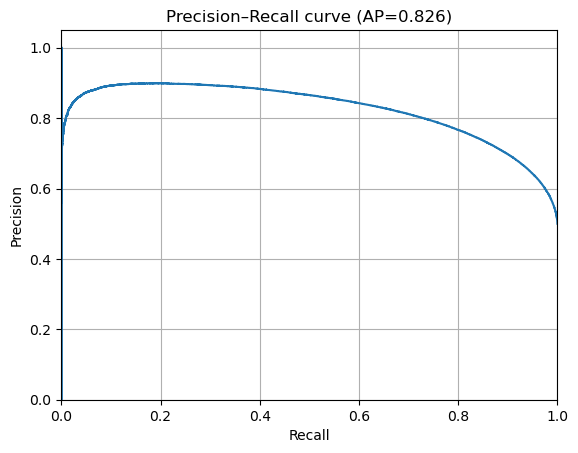

The precision at 0.95 recall is 0.5127


In [72]:
def plot_pr_curve(scores, labels, title="Precision–Recall curve"):
    scores = np.asarray(scores).ravel()
    labels = np.asarray(labels).astype(int).ravel()

    precision, recall, thresholds = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (AP={ap:.3f})")
    plt.ylim(0.0, 1.05)
    plt.xlim(0.0, 1.0)
    plt.grid(True)
    plt.savefig("./figures/PRC_latest.png", dpi=300)
    plt.show()

labels, scores = labscore(scores_test, scores_mod)
plot_pr_curve(scores, labels)

def precision_at_threshold(scores, labels, recall):
    threshold = torch.quantile(torch.Tensor(scores[labels == 0]), 1.0-recall)
    scores = torch.as_tensor(scores)
    labels = torch.as_tensor(labels)

    preds = (scores >= threshold).long()  # predicted anomalies

    tp = ((preds == 1) & (labels == 1)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()

    precision = tp / (tp + fp + 1e-8)
    return precision

target_recall = 0.95
prec = precision_at_threshold(scores, labels, target_recall)
print(f"The precision at {target_recall} recall is {prec:.4f}")

In [60]:
np.unique(labels, return_counts=True)

(array([0., 1.], dtype=float32), array([200002, 200000]))

In [73]:
#per k-mer evaluation
base_map = {0: "A", 1: "C", 2: "G", 3: "T"}

def kmer_from_window(x):
    idx = x[:, :4].argmax(dim=1).cpu().numpy()
    return "".join(base_map[int(i)] for i in idx)

def evaluate_per_kmer(model, loader, device="cuda"):
    model.eval()
    loss_dict = defaultdict(list)

    with torch.no_grad():
        for x, lb, pos in loader:
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))  # [B]

            # Decode k-mer for every datum in the batch
            for i in range(x.size(0)):
                kmer = kmer_from_window(x[i])
                loss_dict[kmer].append(float(recon_score[i].detach().cpu()))

    return loss_dict

# {kmer: [loss]}
un_loss = evaluate_per_kmer(model, test_loader)   
mod_loss= evaluate_per_kmer(model, mod_loader)

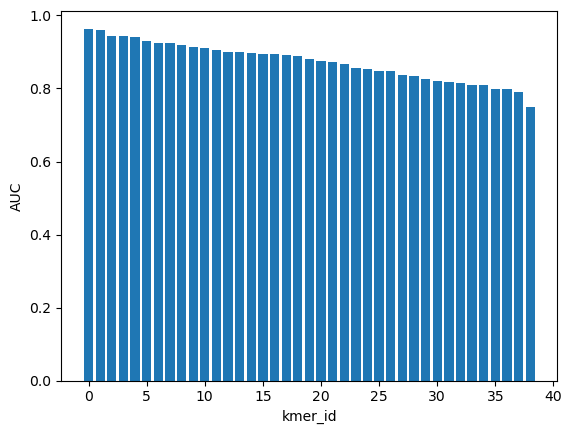

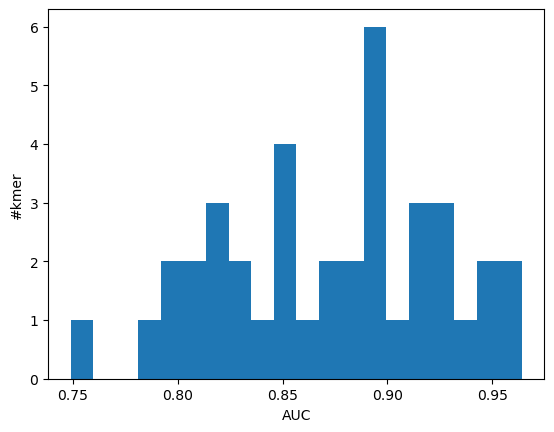

In [74]:
def ROCbykmer(un_loss, mod_loss):
    kmer_stats = []
    
    for km in un_loss.keys():
        un_arr = np.array(un_loss[km])
        mod_arr= np.array(mod_loss.get(km, []))
    
        if len(mod_arr) == 0: #skip kmers absent in mod set
            continue
    
        mean_un = un_arr.mean()
        mean_mod= mod_arr.mean()
    
        # ROC for this k-mer
        labels, scores = labscore(un_arr, mod_arr)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        aucs = auc(fpr, tpr)
        kmer_stats.append((km, len(un_arr), len(mod_arr), mean_un, mean_mod, aucs))

    kmer_stats.sort(key=lambda t: t[-1], reverse=True)
    return pd.DataFrame(kmer_stats, columns=['kmer','#un','#mod','mean_un','mean_mod','auc'])
    
aucs = ROCbykmer(un_loss, mod_loss)

plt.bar(aucs.index, aucs.auc)
plt.xlabel("kmer_id")
plt.ylabel("AUC")
plt.savefig("./figures/kmer-bar_latest.png", dpi=300)
plt.show()

plt.hist(aucs.auc, bins=20)
plt.xlabel("AUC")
plt.ylabel("#kmer")
plt.savefig("./figures/kmer-auc_latest.png", dpi=300)
plt.show()

In [68]:
def evaluate_per_read(model, loader, device="cuda"):
    loss_list, label_list, pos_list = [], [], []
    model.eval()

    with torch.no_grad():
        for x, y, pos in loader:                 # batch
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))

            loss_list.extend(recon_score.detach().cpu().tolist())
            label_list.extend(y.cpu().tolist())
            pos_list.extend(pos.cpu().tolist())

    return loss_list, label_list, pos_list

# aggregate score by position
def aggregate_by_site(losses, labels, positions, agg="mean"):
    score_dict  = defaultdict(list)
    label_dict  = defaultdict(list)

    for s, l, p in zip(losses, labels, positions):
        ps = str(p[2])+'-'+str(p[1])
        score_dict[ps].append(s)
        label_dict[ps].append(l)

    site_score  = []
    site_label  = []

    for p in score_dict:
        vals = np.array(score_dict[p])
        if agg == "median":
            site_score.append(np.median(vals))
        elif agg == "max":
            site_score.append(np.max(vals))
        else:
            site_score.append(np.mean(vals))

        # majority vote for label, or "any-mod" rule
        lab = np.array(label_dict[p])
        site_label.append(int((lab == 1).any()))   # 1 if ≥1 mod read

    return np.array(site_score), np.array(site_label)


loss_r1, lab_r1, pos_r1 = evaluate_per_read(model, test_loader)
loss_r2, lab_r2, pos_r2 = evaluate_per_read(model, mod_loader)
pos_r = [list(t) for t in (set(map(tuple, pos_r1)) & set(map(tuple, pos_r2)))]
score_site1, label_site1 = aggregate_by_site(loss_r1, lab_r1, pos_r, agg="mean")
score_site2, label_site2 = aggregate_by_site(loss_r2, lab_r2, pos_r, agg="mean")
score_site = np.concat([score_site1, score_site2])
label_site = np.concat([label_site1, label_site2])

# ROC at site level
fpr, tpr, thresholds = roc_curve(label_site, score_site)
auc_site = auc(fpr, tpr)

print(f"Site-level ROC-AUC = {auc_site:.3f}  (N_sites = {len(score_site)})")

Site-level ROC-AUC = 1.000  (N_sites = 74)


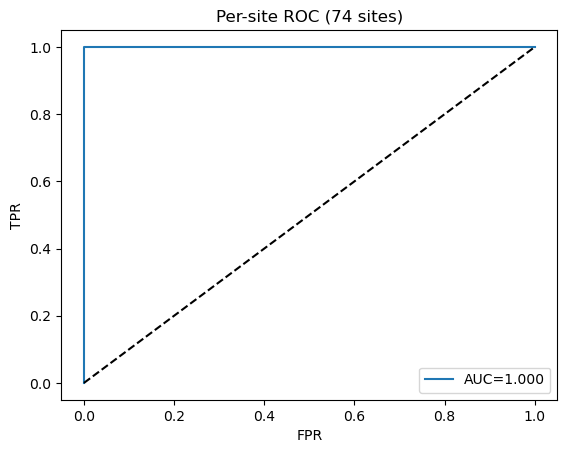

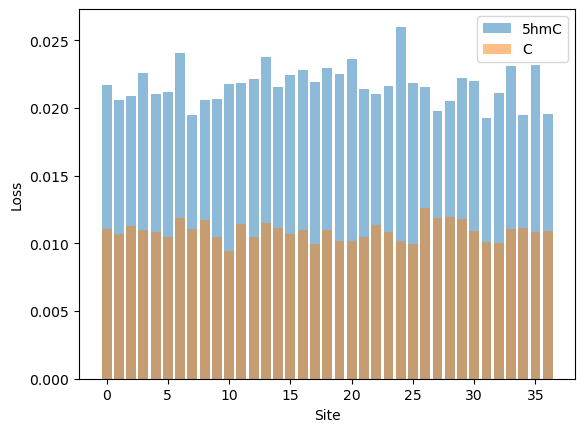

In [70]:
def plotSite(bar=True):
    plt.plot(fpr, tpr, label=f"AUC={auc_site:.3f}")
    plt.plot([0,1],[0,1],'k--'); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"Per-site ROC ({len(score_site)} sites)"); plt.legend()
    plt.savefig("./figures/site-ROC_latest.png", dpi=300)
    plt.show()
    if bar:
        plt.bar(list(range(len(score_site2))), score_site2, alpha=0.5, label='5hmC');
        plt.bar(list(range(len(score_site1))), score_site1, alpha=0.5, label='C');
        plt.xlabel("Site")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig("./figures/site-bar_latest.png", dpi=300)
        plt.show()

plotSite(bar=1)


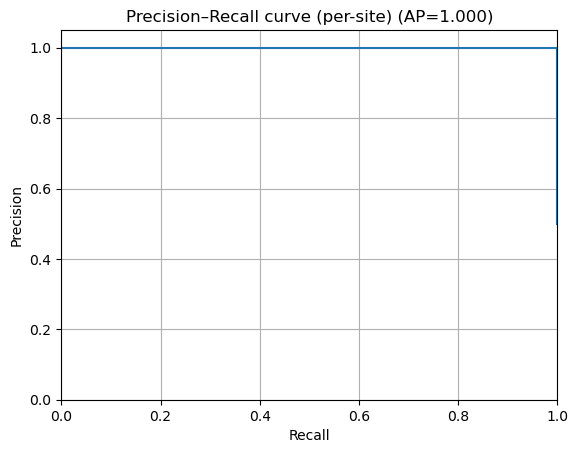

In [75]:
def plot_pr_curve(scores, labels, title="Precision–Recall curve (per-site)"):
    scores = np.asarray(scores).ravel()
    labels = np.asarray(labels).astype(int).ravel()

    precision, recall, thresholds = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (AP={ap:.3f})")
    plt.ylim(0.0, 1.05)
    plt.xlim(0.0, 1.0)
    plt.grid(True)
    plt.savefig("./figures/site-PRC_latest.png", dpi=300)
    plt.show()
    
plot_pr_curve(score_site, label_site)